## Import libraries

In [217]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [218]:
players_df = pd.read_csv("cricket_players_analysis.csv")
stats_df = pd.read_csv("cricket_match_stats_analysis.csv")

## dataset overview

In [219]:
players_df.head()

,Player_ID,Player_Name,Team,Role,Age
0,P0001,Player_1,MI,Batsman,26
1,P0002,Player_2,KKR,Bowler,22
2,P0003,Player_3,MI,Batsman,36
3,P0004,Player_4,DC,Batsman,18
4,P0005,Player_5,MI,Bowler,25


In [220]:
stats_df.head()

,Match_ID,Player_ID,Runs,Wickets,Strike_Rate,Match_Date
0,M00001,P1371,15,1,84.72,2025/03/10
1,M00002,P3786,15,1,133.90,2025-01-15
2,M00003,P1417,18,3,151.69,2025-01-15
3,M00004,P3636,141,3,210.92,2025/03/10
4,M00005,P2963,10,0,56.05,15/02/2025


In [221]:
players_df.shape


(4050, 5)

In [222]:
stats_df.shape

(5075, 6)

In [223]:
players_df.info()

stats_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4050 entries, 0 to 4049
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Player_ID    4050 non-null   object
 1   Player_Name  3988 non-null   object
 2   Team         4050 non-null   object
 3   Role         4050 non-null   object
 4   Age          4050 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 158.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5075 entries, 0 to 5074
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Match_ID     5075 non-null   object 
 1   Player_ID    5044 non-null   object 
 2   Runs         5075 non-null   int64  
 3   Wickets      5075 non-null   int64  
 4   Strike_Rate  5013 non-null   float64
 5   Match_Date   5075 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 238.0+ KB


### Missing Values

In [224]:
players_df.isnull().sum()

Player_ID       0
Player_Name    62
Team            0
Role            0
Age             0
dtype: int64

In [225]:
stats_df.isnull().sum()

Match_ID        0
Player_ID      31
Runs            0
Wickets         0
Strike_Rate    62
Match_Date      0
dtype: int64

### Duplicate Records


In [226]:
players_df.duplicated().sum()

np.int64(50)

In [227]:
stats_df.duplicated().sum()

np.int64(75)

### Remove Duplicates

In [228]:
players_df.drop_duplicates(inplace=True)

In [229]:
stats_df.drop_duplicates(inplace=True)

In [230]:
## Merge Datasets
merged_df = pd.merge(
    players_df,
    stats_df,
    on='Player_ID',
    how='inner'
)

In [231]:
merged_df.head()

,Player_ID,Player_Name,Team,Role,Age,Match_ID,Runs,Wickets,Strike_Rate,Match_Date
0,P0002,Player_2,KKR,Bowler,22,M00488,19,2,170.42,2025/03/10
1,P0003,Player_3,MI,Batsman,36,M00973,16,1,196.00,2025/03/10
2,P0004,Player_4,DC,Batsman,18,M00248,37,1,200.10,2025/03/10
3,P0004,Player_4,DC,Batsman,18,M02749,33,6,99.92,Apr 12 2025
4,P0005,Player_5,MI,Bowler,25,M02395,38,3,73.93,2025/03/10


In [232]:
merged_df.shape

(5129, 10)

### Invalid Values

In [233]:
merged_df.loc[
    merged_df['Runs'] < 0,
    'Runs'
] = 0

In [234]:
merged_df['Wickets'] = merged_df[
    'Wickets'
].clip(
    lower=0,
    upper=10
)

##  Data Cleaning

### Runs

In [235]:
merged_df['Runs'] = pd.to_numeric(
    merged_df['Runs'],
    errors='coerce'
)



### Wickets

In [236]:
merged_df['Wickets'] = pd.to_numeric(
    merged_df['Wickets'],
    errors='coerce'
)

### Strike Rate

In [237]:
merged_df['Strike_Rate'] = pd.to_numeric(
    merged_df['Strike_Rate'],
    errors='coerce'
)

### Age

In [238]:
merged_df['Age'] = pd.to_numeric(
    merged_df['Age'],
    errors='coerce'
)



### Team

In [239]:
merged_df['Team'] = (
    merged_df['Team']
    .astype(str)
    .str.upper()
    .str.strip()
)

In [240]:
team_mapping = {
    'RCB': 'RCB',
    'ROYAL CHALLENGERS': 'RCB',
    'ROYAL CHALLENGERS BANGALORE': 'RCB'
}

merged_df['Team'] = merged_df['Team'].replace(team_mapping)

### Match Date

In [241]:
merged_df['Match_Date'] = pd.to_datetime(
    merged_df['Match_Date'],
    format='mixed',
    errors='coerce'
)

merged_df.dropna(
    subset=['Match_Date'],
    inplace=True
)

### Validation

In [242]:
merged_df.dropna()
merged_df.shape

merged_df.isnull().sum()


merged_df.duplicated().sum()

np.int64(0)

### Data Transformation

In [243]:
merged_df['Month'] = merged_df['Match_Date'].dt.month

merged_df['Year'] = merged_df['Match_Date'].dt.year

### Create Age Group

In [244]:
merged_df['Age_Group'] = pd.cut(
    merged_df['Age'],
    bins=[0,20,30,40,50],
    labels=[
        '<20',
        '20-30',
        '30-40',
        '40+'
    ]
)

### Performance Category

In [245]:
merged_df['Performance'] = pd.cut(
    merged_df['Runs'],
    bins=[-1, 30, 60, 100, float('inf')],
    labels=['Low', 'Average', 'Good', 'Excellent']
)

### Total Contribution

In [246]:
merged_df['Total_Contribution'] = (
    merged_df['Runs']
    +
    merged_df['Wickets']
)

### Team Summary

In [247]:
team_summary = merged_df.groupby(
    'Team'
).agg({
    'Runs':'sum',
    'Wickets':'sum',
    'Strike_Rate':'mean'
})

team_summary

,Runs,Wickets,Strike_Rate
Team,,,
CSK,35551,1467,134.459670
DC,37000,1462,135.314193
GT,37094,1531,137.686375
KKR,36723,1423,134.962619
LSG,40997,1612,134.857293
MI,38056,1545,133.760777
PBKS,38188,1641,137.015038
RCB,44856,1788,136.035060
RR,37859,1511,133.626493


### Player Summary

In [248]:
player_summary = merged_df.groupby(
    'Player_Name'
).agg({
    'Runs':'sum',
    'Wickets':'sum',
    'Strike_Rate':'mean'
})

player_summary.head()

,Runs,Wickets,Strike_Rate
Player_Name,,,
Player_10,284,6,215.040
Player_1001,119,6,154.235
Player_1002,114,4,170.220
Player_1003,65,6,175.700
Player_1005,146,3,143.995


In [249]:
merged_df['Runs_per_Wicket'] = merged_df['Runs'] / (merged_df['Wickets'] + 1)

merged_df['Performance_Score'] = (
    merged_df['Runs'] * 0.7 +
    merged_df['Wickets'] * 20
)

merged_df.head()

,Player_ID,Player_Name,Team,Role,Age,Match_ID,Runs,Wickets,Strike_Rate,Match_Date,Month,Year,Age_Group,Performance,Total_Contribution,Runs_per_Wicket,Performance_Score
0,P0002,Player_2,KKR,Bowler,22,M00488,19,2,170.42,2025-03-10,3,2025,20-30,Low,21,6.333333,53.3
1,P0003,Player_3,MI,Batsman,36,M00973,16,1,196.00,2025-03-10,3,2025,30-40,Low,17,8.000000,31.2
2,P0004,Player_4,DC,Batsman,18,M00248,37,1,200.10,2025-03-10,3,2025,<20,Average,38,18.500000,45.9
3,P0004,Player_4,DC,Batsman,18,M02749,33,6,99.92,2025-04-12,4,2025,<20,Average,39,4.714286,143.1
4,P0005,Player_5,MI,Bowler,25,M02395,38,3,73.93,2025-03-10,3,2025,20-30,Average,41,9.500000,86.6


## Data Analysis

### 1.Top 10 Run Scorers

In [250]:
top_runs = merged_df.groupby(
'Player_Name'
)['Runs'].sum().sort_values(
ascending=False
).head(10)

top_runs

Player_Name
Player_95      1180
Player_99      1060
Player_93       884
Player_76       666
Player_1463     604
Player_2487     587
Player_88       572
Player_1674     565
Player_1341     552
Player_94       550
Name: Runs, dtype: int64

### 2.Top 10 Wicket Takers

In [251]:
top_wickets = merged_df.groupby(
'Player_Name'
)['Wickets'].sum().sort_values(
ascending=False
).head(10)

top_wickets

Player_Name
Player_95      38
Player_71      32
Player_43      28
Player_3141    25
Player_1526    24
Player_711     23
Player_93      22
Player_65      22
Player_1064    22
Player_707     22
Name: Wickets, dtype: int64

### 3.Team-wise Runs

In [252]:
team_runs = merged_df.groupby(
'Team'
)['Runs'].sum()

### 4.Team-wise Wickets

In [253]:
team_wickets = merged_df.groupby(
'Team'
)['Wickets'].sum()

### 5.Role Distribution

In [254]:
merged_df['Role'].value_counts()

Role
Batsman          1331
Wicket Keeper    1300
Bowler           1289
All-Rounder      1209
Name: count, dtype: int64

### 6.Average Strike Rate by Team

In [255]:
team_sr = merged_df.groupby(
'Team'
)['Strike_Rate'].mean()

### 8.Age Group Analysis

In [256]:
merged_df.groupby(
    'Age_Group'
)['Runs'].mean()

C:\Users\priya\AppData\Local\Temp\ipykernel_40156\1186902585.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby(


Age_Group
<20      74.625000
20-30    74.531703
30-40    75.230524
40+            NaN
Name: Runs, dtype: float64

### 9.Monthly Runs Trend

In [257]:

merged_df['Match_Date'] = pd.to_datetime(
    merged_df['Match_Date'],
    errors='coerce'
)

# Check invalid dates
merged_df['Match_Date'].isnull().sum()

# Extract month
merged_df['Month'] = merged_df['Match_Date'].dt.month

# Monthly runs
monthly_runs = merged_df.groupby('Month')['Runs'].sum()

# Display output
monthly_runs



Month
1    99911
2    94297
3    95320
4    94040
Name: Runs, dtype: int64

## Data Visualization

### 1.Top 10 Run Scorers

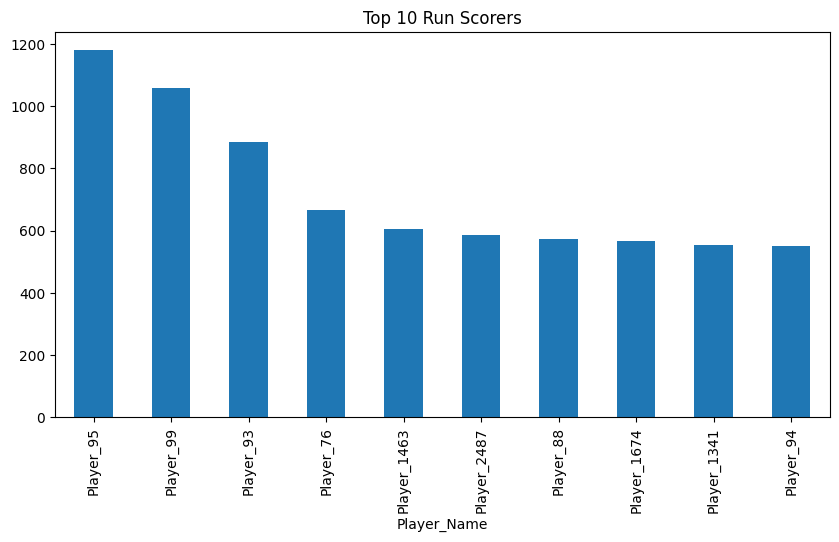

In [258]:
top_runs.plot(
kind='bar',
figsize=(10,5)
)

plt.title(
'Top 10 Run Scorers'
)

plt.show()

### 2.Top 10 Wicket Takers

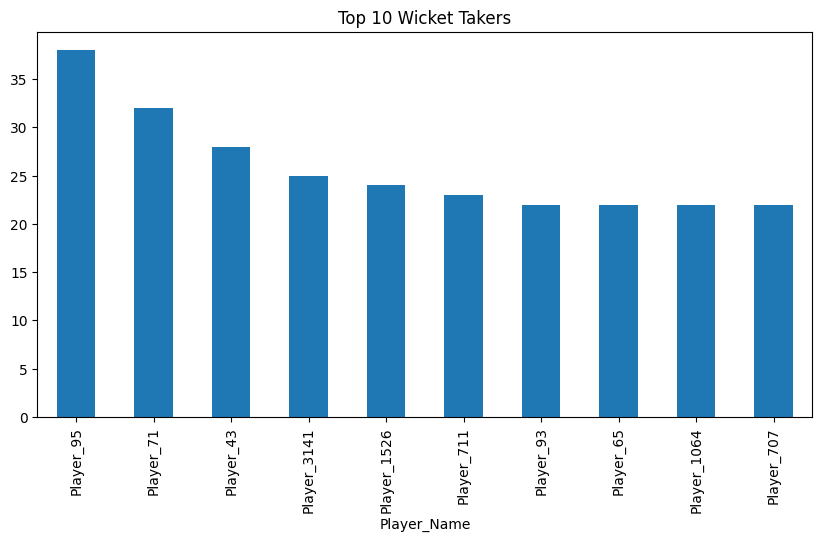

In [259]:
top_wickets.plot(
kind='bar',
figsize=(10,5)
)

plt.title(
'Top 10 Wicket Takers'
)

plt.show()

### 3.Team-wise Total Runs

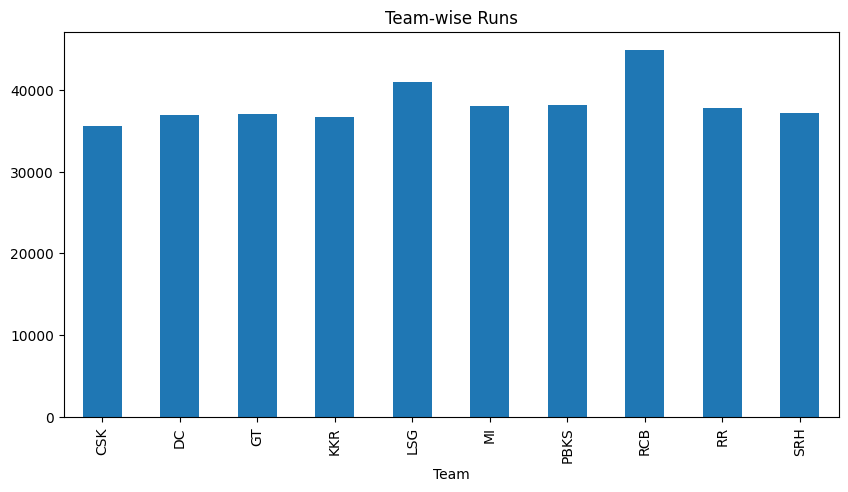

In [260]:
team_runs.plot(
kind='bar',
figsize=(10,5)
)

plt.title(
'Team-wise Runs'
)

plt.show()

### 4. Team-wise Total Wickets

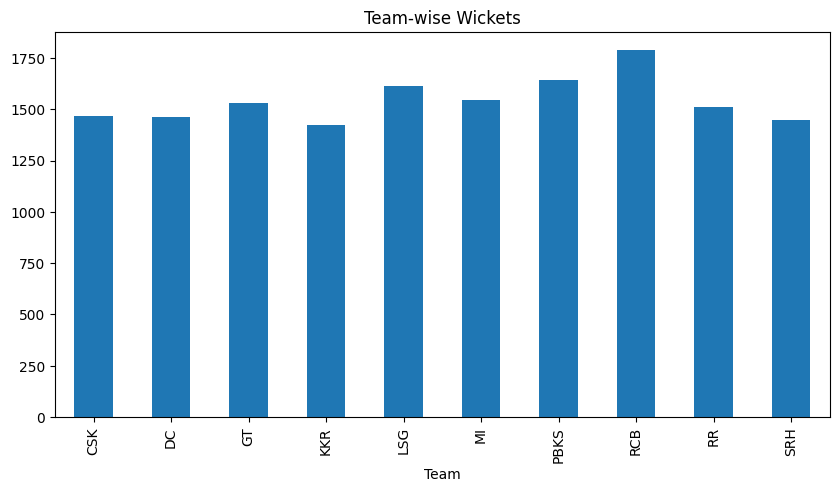

In [261]:
team_wickets = merged_df.groupby(
    'Team'
)['Wickets'].sum()

team_wickets.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Team-wise Wickets')
plt.show()

### 5. Player Role Distribution

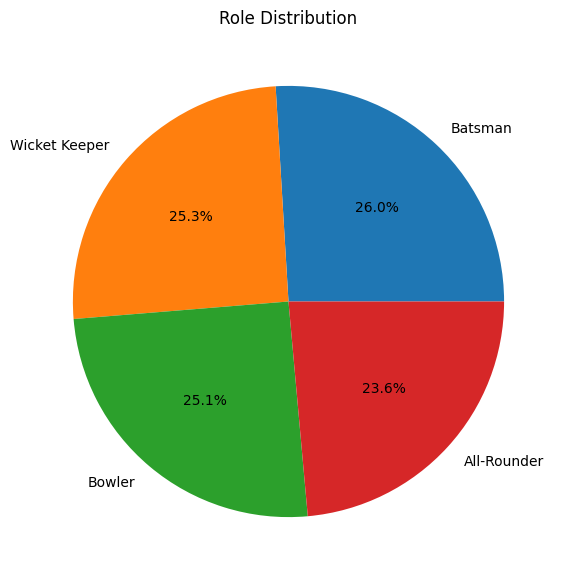

In [262]:
role = merged_df['Role'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    role,
    labels=role.index,
    autopct='%1.1f%%'
)

plt.title('Role Distribution')
plt.show()

###  6. Age Distribution

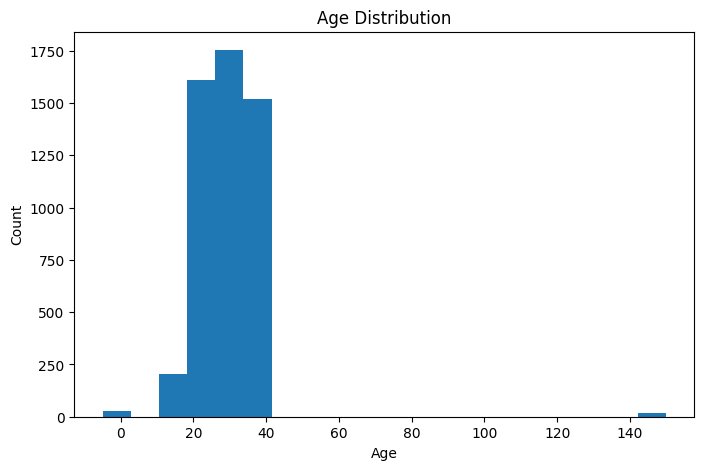

In [263]:
plt.figure(figsize=(8,5))
plt.hist(merged_df['Age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### 7. Average Strike Rate by Team

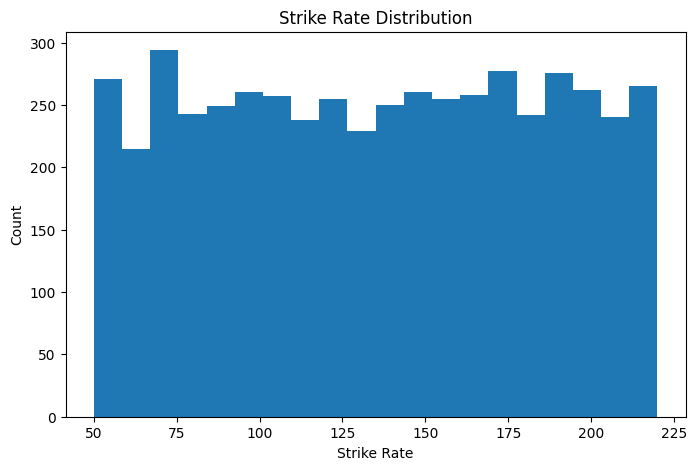

In [264]:
plt.figure(figsize=(8,5))
plt.hist(merged_df['Strike_Rate'], bins=20)
plt.title('Strike Rate Distribution')
plt.xlabel('Strike Rate')
plt.ylabel('Count')
plt.show()

### 8. Monthly Runs Trend

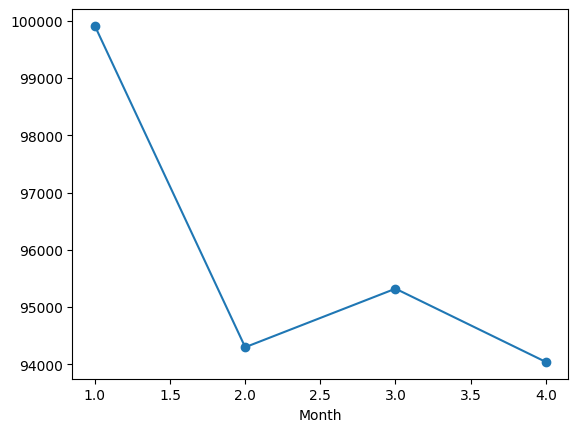

In [265]:
monthly_runs = merged_df.groupby(
'Month'
)['Runs'].sum()

monthly_runs.plot(
marker='o'
)

plt.show()

### 9. Correlation Heatmap

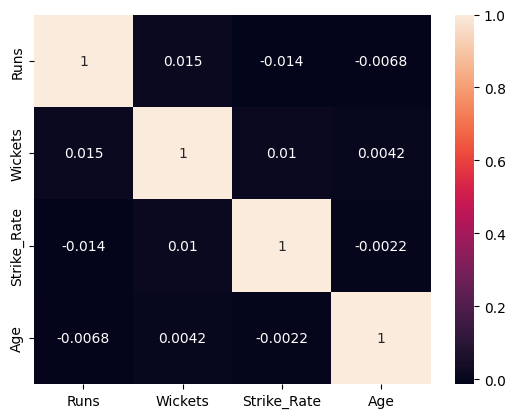

In [266]:
sns.heatmap(
merged_df[
['Runs',
'Wickets',
'Strike_Rate',
'Age']
].corr(),
annot=True
)

plt.show()

### 10. Top All-Rounders

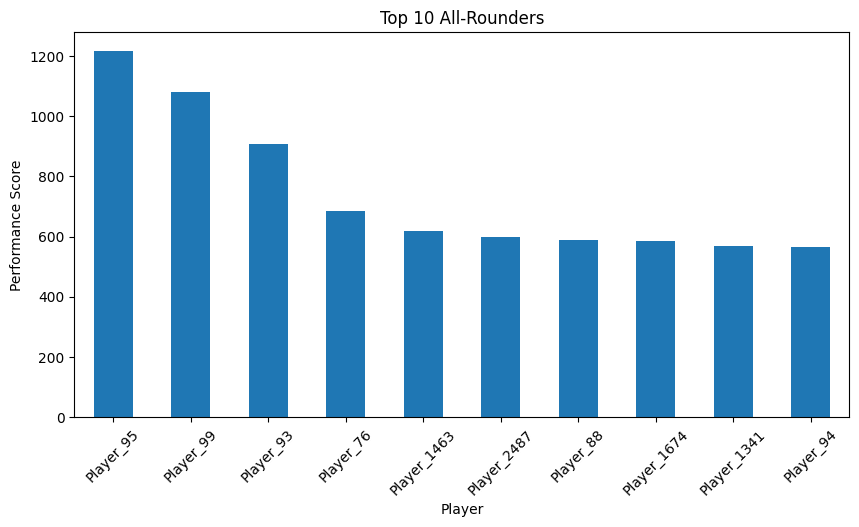

In [267]:
all_rounders = merged_df.groupby('Player_Name').agg({
    'Runs':'sum',
    'Wickets':'sum'
})

all_rounders['Total'] = (
    all_rounders['Runs'] +
    all_rounders['Wickets']
)

top_all_rounders = all_rounders.sort_values(
    by='Total',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

top_all_rounders['Total'].plot(
    kind='bar'
)

plt.title('Top 10 All-Rounders')
plt.xlabel('Player')
plt.ylabel('Performance Score')
plt.xticks(rotation=45)
plt.show()

In [268]:
# Save Final Dataset
merged_df.to_csv(
    "final_cleaned_cricket_data.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


# Conclusion

This project includes:

- Data Collection
- Data Merging
- Data Cleaning
- Data Transformation
- Exploratory Data Analysis
- Data Visualization

The dataset was cleaned by handling missing values, removing duplicates, and standardizing team names such as RCB and Royal Challengers Bangalore. Various analyses and visualizations were performed to identify player and team performance trends.

# Project Summary

This project analyzes cricket player and match statistics using Python. Data was collected, merged, cleaned, transformed and visualized to identify player performance trends, team statistics and key insights.